In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              roc_curve, classification_report)
from sklearn.impute import SimpleImputer
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [6]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Google Colab/SVM&KNN/Titanic-Dataset.csv')

print("Dataset loaded! Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded! Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Preprocessing

In [7]:
# 1. Select useful features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

df_clean = df[features + [target]].copy()

# 2. Handle missing values (Imputation)
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['Fare'].fillna(df_clean['Fare'].median(), inplace=True)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Encode categorical features
le_sex = LabelEncoder()
df_clean['Sex'] = le_sex.fit_transform(df_clean['Sex'])  # male=1, female=0

le_emb = LabelEncoder()
df_clean['Embarked'] = le_emb.fit_transform(df_clean['Embarked'])  # C=0, Q=1, S=2

print("Missing values after cleaning:", df_clean.isnull().sum().sum())
print("\nData types:")
print(df_clean.dtypes)
print("\nShape:", df_clean.shape)

Missing values after cleaning: 0

Data types:
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
Survived      int64
dtype: object

Shape: (891, 8)


# Split data into Train / Validation / Test sets

In [8]:
# --- Split data into Train (70%) / Validation (15%) / Test (15%) ---

X = df_clean[features]
y = df_clean[target]

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

# Second split: 50/50 of temp = 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Scale features (CRITICAL for KNN!)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Training set:   {X_train_sc.shape[0]} samples")
print(f"Validation set: {X_val_sc.shape[0]} samples")
print(f"Test set:       {X_test_sc.shape[0]} samples")

Training set:   623 samples
Validation set: 134 samples
Test set:       134 samples


# Elbow Method — find best K value

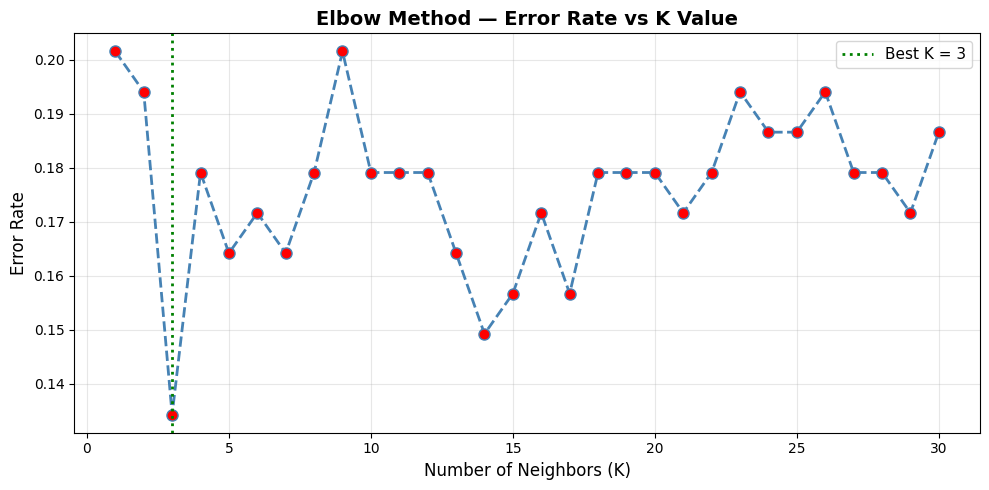

Best K value from Elbow Method: 3


In [9]:
error_rates = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    pred = knn.predict(X_val_sc)
    error_rates.append(1 - accuracy_score(y_val, pred))

plt.figure(figsize=(10, 5))
plt.plot(k_range, error_rates, color='steelblue', linestyle='--',
         marker='o', markerfacecolor='red', markersize=8, linewidth=2)
best_k = k_range[error_rates.index(min(error_rates))]
plt.axvline(x=best_k, color='green', linestyle=':', linewidth=2,
            label=f'Best K = {best_k}')
plt.title('Elbow Method — Error Rate vs K Value', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best K value from Elbow Method: {best_k}")

# Hyperparameter tuning with Grid Search

In [10]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean', 'manhattan']
}

knn_base = KNeighborsClassifier()
grid_search = GridSearchCV(knn_base, param_grid, cv=5,
                            scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_sc, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Use best model
best_knn = grid_search.best_estimator_

Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.8250


# Evaluate the model — metrics & confusion matrix

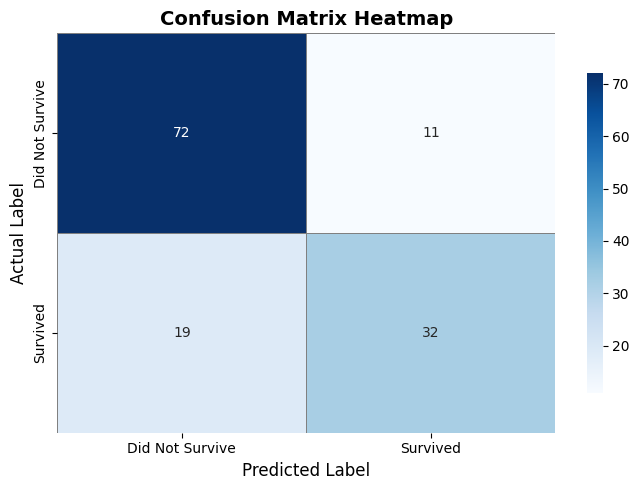

        MODEL EVALUATION METRICS
  Accuracy  : 0.7761  (77.61%)
  Precision : 0.7442
  Recall    : 0.6275
  F1-Score  : 0.6809
  AUC       : 0.8304

Detailed Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.79      0.87      0.83        83
       Survived       0.74      0.63      0.68        51

       accuracy                           0.78       134
      macro avg       0.77      0.75      0.75       134
   weighted avg       0.77      0.78      0.77       134



In [11]:
# --- Evaluation: Confusion Matrix + Metrics ---

y_pred = best_knn.predict(X_test_sc)
y_prob = best_knn.predict_proba(X_test_sc)[:, 1]

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'],
            linewidths=0.5, linecolor='gray', cbar_kws={'shrink': 0.8})
plt.title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print all metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("        MODEL EVALUATION METRICS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC       : {auc:.4f}")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive','Survived']))

# ROC Curve

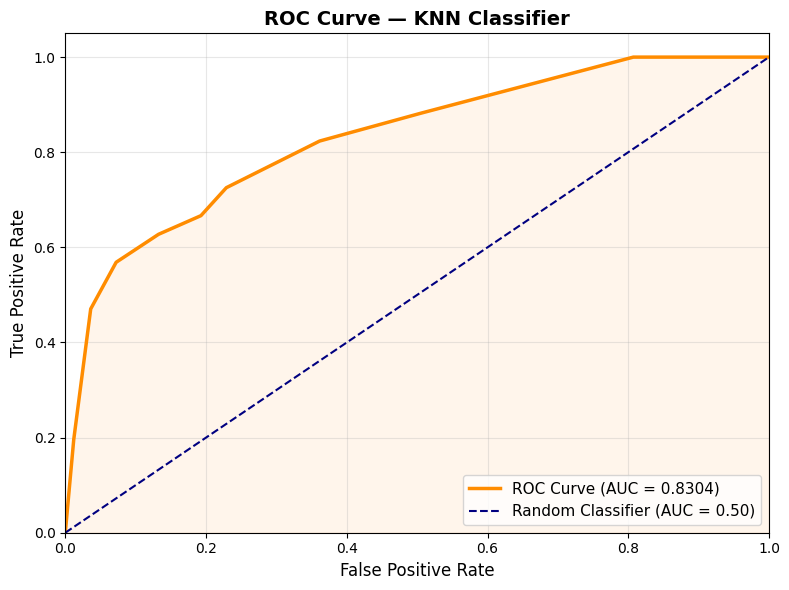

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — KNN Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# 2D Decision Boundary Plot

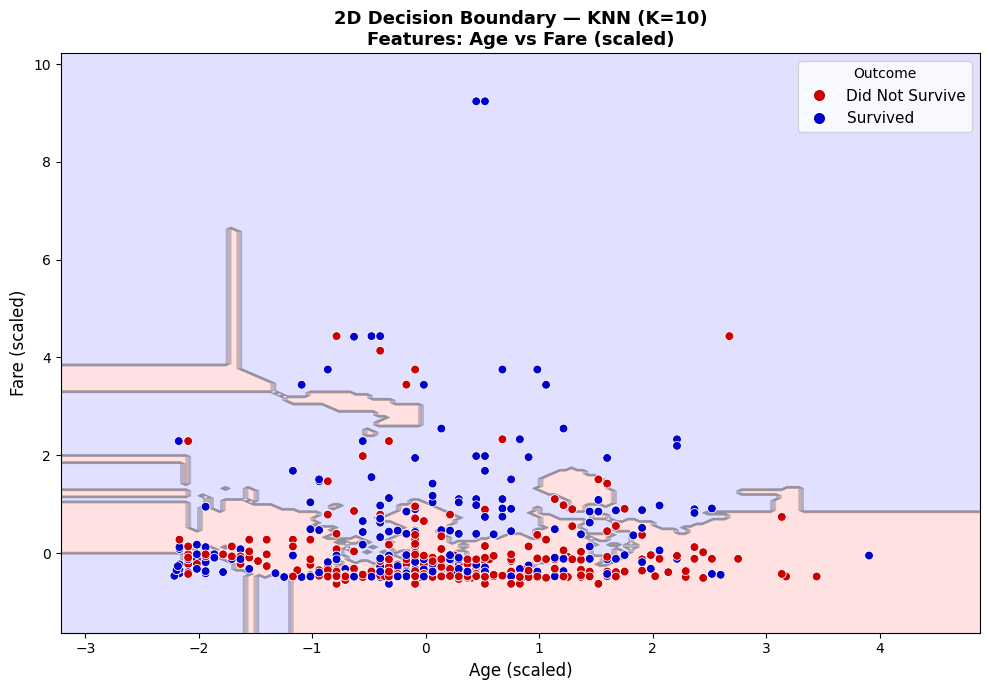

In [14]:

X2 = df_clean[['Age', 'Fare']].values
y2 = df_clean['Survived'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

best_params = grid_search.best_params_
knn2 = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    metric=best_params['metric'])
knn2.fit(X2_train_sc, y2_train)


h = 0.05
x_min, x_max = X2_train_sc[:, 0].min() - 1, X2_train_sc[:, 0].max() + 1
y_min, y_max = X2_train_sc[:, 1].min() - 1, X2_train_sc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


cmap_bg = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_pt = ListedColormap(['#CC0000', '#0000CC'])

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
plt.contour(xx, yy, Z, colors='gray', linewidths=0.5, alpha=0.5)
scatter = plt.scatter(X2_train_sc[:, 0], X2_train_sc[:, 1],
                       c=y2_train, cmap=cmap_pt,
                       edgecolors='white', s=40, linewidth=0.6, zorder=3)
plt.title(f'2D Decision Boundary — KNN (K={best_params["n_neighbors"]})\n'
          f'Features: Age vs Fare (scaled)',
          fontsize=13, fontweight='bold')
plt.xlabel('Age (scaled)', fontsize=12)
plt.ylabel('Fare (scaled)', fontsize=12)
legend_labels = ['Did Not Survive', 'Survived']
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=9) for c in ['#CC0000', '#0000CC']]
plt.legend(handles, legend_labels, title='Outcome', fontsize=11)
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()